In [45]:
import os
import caesar
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
import modules as anal
import modules.anal_func as anal_func

from astropy.cosmology import LambdaCDM
import astropy.units as u
from astropy.io import fits
from scipy import interpolate

from modules.anal_func.build_history import BuildHistory
from modules.anal_func.read_progenitors import read_progen

from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np


cosmo = LambdaCDM(H0 = 68, Om0= 0.3, Ode0= 0.7, Ob0=0.048)
plt.rcParams.update({'font.size': 28})

In [46]:
# initialize the Simba class, which import the needed paths
sb = anal.Simba('PC39BP4', size=100)
# initialize the SavePaths class to create destinations
sv = anal.SavePaths() 
pltsv  = sv.get_filetype_path('plot')
scatter = sv.create_subdir(pltsv, 'scatter')

In [47]:
cs = sb.get_caesar(45)
totids = np.asarray([i.GroupID for i in cs.galaxies])
sfh = BuildHistory(sb, '/home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5', progfilename='progenitors_recursive.fits')#'progenitors_recursive.fits') #'progenitors_most_mass_nocaesar.fits')

yt : [INFO     ] 2025-06-14 18:48:09,619 Opening /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_045.hdf5
yt : [INFO     ] 2025-06-14 18:48:09,628 Found 320267 halos
yt : [INFO     ] 2025-06-14 18:48:09,631 Found 14221 galaxies


In [48]:
hist = sfh.get_history_indx(totids[:], start_snap=45, end_snap=149)

In [49]:
positions = sfh.get_property_history(['pos_0', 'pos_1' , 'pos_2', 'GroupID', 'sfr', 'stellar_masses'])

Number of snapshots: 105
Opening /home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5/m100n1024_045.fits
Opening /home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5/m100n1024_046.fits
Error processing snapshot 46: index 15508 is out of bounds for axis 0 with size 15089
Opening /home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5/m100n1024_047.fits
Error processing snapshot 47: index 16580 is out of bounds for axis 0 with size 15969
Opening /home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5/m100n1024_048.fits
Error processing snapshot 48: index 17487 is out of bounds for axis 0 with size 16784
Opening /home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5/m100n1024_049.fits
Error processing snapshot 49: index 18322 is out of bounds for axis 0 with size 17603
Opening /home/lorenzong/analize_simba_cgm/output/fits/converted_from_hdf5/m100n1024_050.fits
Error processing snapshot 50: index 18688 is out of bounds for axis 0 wit

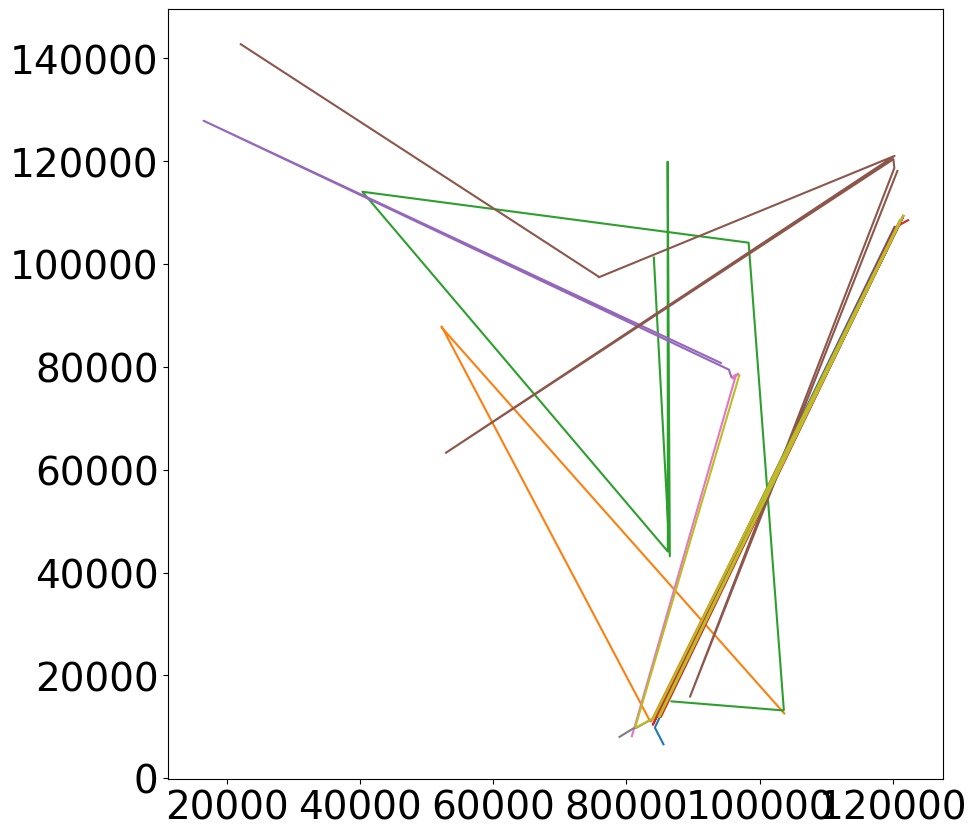

In [38]:
plt.figure(figsize=(10, 10))
for i in range(len(positions['pos_0'][:10])):
    plt.plot(positions['pos_0'][:,i], positions['pos_1'][:,i])

[8.52402734e+04 1.21743461e+05 9.69936016e+04 1.39354854e+04
 9.71602891e+04 8.01167188e+04 9.72150859e+04 1.98902812e+04
 5.22496289e+04 6.04288086e+03 1.71042793e+04 3.31988203e+04
 8.88543281e+04 3.52220469e+04 9.34363125e+04 9.51351367e+03
 9.63841875e+04 1.33727148e+04 1.30250342e+04 1.45782172e+05
 7.95114795e+03 1.20807828e+05 4.00860391e+04 5.63772070e+04
 8.58557578e+04 5.17391943e+03 1.29046711e+05 1.33923916e+04
 1.16076113e+04 8.66889141e+04 1.32811766e+05 1.36259781e+05
 8.70935625e+04 1.02428328e+05 9.00427500e+04 8.39005000e+04
 7.46394766e+04 1.44067344e+04 8.51616172e+04 5.66308867e+04
 1.45547516e+05 9.38085234e+04 9.53510859e+04 1.09425820e+05
 1.88930273e+04 9.25986016e+04 1.97907852e+04 2.67071328e+04
 1.46471846e+04 1.05335125e+05 9.52989531e+04 7.14771338e+03
 7.57242344e+04 1.08546438e+05 3.94707383e+04 1.02239766e+05
 7.54603043e+01 6.12130273e+04 7.40093047e+04 8.32464297e+04
 1.37095430e+04 9.54124688e+04 1.71164160e+04 9.99396953e+04
 5.45885469e+04 5.111827

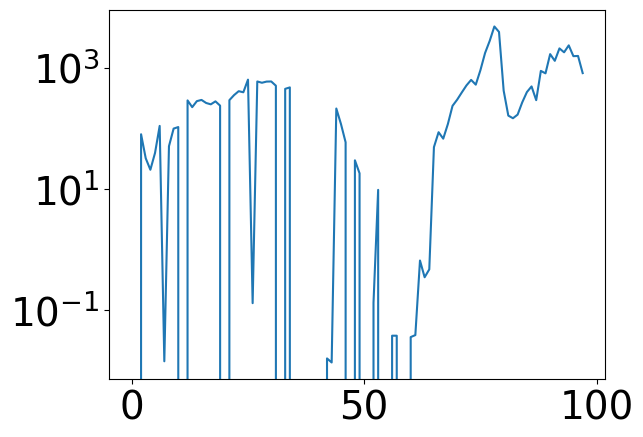

In [45]:
plt.plot(positions['sfr'][:,0])
plt.yscale('log')

In [ ]:
# define our redshift range
z = sb.get_z_from_snap(np.arange(44, 150, 1))
tcosmo = cosmo.age(z).value

indx = -16
print('z = ', z[indx])
print(np.log10(0.2/cosmo.age(z[indx]).to(u.yr).value), 'Gyr')

In [ ]:
# Specific SFR selection
ssfr = np.log10(positions['sfr'][indx, :] / positions['stellar_masses'][indx, :])
ssfr_cut = ssfr < np.log10(0.2/cosmo.age(z[indx]).to(u.yr).value)
galaxy_selection = np.where(ssfr_cut)[0]
print(f"Number of galaxies selected: {len(galaxy_selection)} over {len(positions['stellar_masses'][indx, :])} total galaxies.")


In [ ]:
import numpy as np

def find_mergers(gal_data, target_ids, indx, z, distance_thresh=0.1, min_consecutive=2):
    """
    Identify potential mergers based on 3D proximity over consecutive snapshots.
    
    Parameters
    ----------
    gal_data : dict
        Dictionary with keys 'pos_x', 'pos_y', 'pos_z', and 'GroupID'.
    target_ids : array-like
        GroupIDs of target galaxies to analyze.
    distance_thresh : float
        Distance threshold in Mpc (default 0.1 = 100 kpc).
    min_consecutive : int
        Minimum number of consecutive snapshots for a close passage.
    
    Returns
    -------
    mergers : dict
        Dictionary mapping each target GroupID to a set of merging GroupIDs.
    """
    pos_x = np.array(gal_data['pos_0'])  # shape (n_snap, n_gal)
    pos_y = np.array(gal_data['pos_1'])
    pos_z = np.array(gal_data['pos_2'])
    group_ids = np.array(gal_data['GroupID']).astype(int)  # shape (n_gal,)
    
    n_snap, n_gal = pos_x.shape
    positions = np.stack([pos_x, pos_y, pos_z], axis=2)  # shape (n_snap, n_gal, 3)
    
    mergers = {}

    # Find indices of target galaxies
    target_mask = np.isin(group_ids[indx, :], target_ids)
    target_indices = np.where(target_mask)[0]
    print(target_indices)
    print(f"Found {len(target_indices)} target galaxies in snapshot {indx}.")
    for tgt_idx in target_indices:
        print(f"Processing target galaxy {group_ids[indx, tgt_idx]} at index {tgt_idx}...")
        tgt_id = group_ids[indx, tgt_idx]
        tgt_pos = positions[:, tgt_idx, :]  # shape (n_snap, 3)

        # Compute 3D distances to all galaxies across snapshots
        dist = np.linalg.norm(positions - tgt_pos[:, np.newaxis, :], axis=2)*0.68  # (n_snap, n_gal)


        # Apply distance threshold (exclude self)
        close_mask = (dist < distance_thresh)
        close_mask[:, tgt_idx] = False  # remove self-match

        # Track galaxies that are within threshold for ≥min_consecutive snapshots
        potential_mergers = set()
        for gal_idx in range(n_gal):
            close_snapshots = close_mask[:, gal_idx]
            # Check for ≥2 consecutive Trues
            if np.any(np.convolve(close_snapshots.astype(int), np.ones(min_consecutive, dtype=int), mode='valid') >= min_consecutive):
                potential_mergers.add(group_ids[indx, gal_idx])
                #print(f"Found potential merger: {group_ids[indx, gal_idx]}")

        mergers[tgt_id] = potential_mergers

    return mergers


In [ ]:
merger_dict = find_mergers(positions, positions['GroupID'][-1, galaxy_selection][:3], 0, z, distance_thresh=100, min_consecutive=4)


In [ ]:
merger_dict.keys()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

group_ids = positions['GroupID']  # shape (n_snap, n_gal) or maybe (1, n_gal) if static
pos_x = positions['pos_0']  # shape (n_snap, n_gal)
pos_y = positions['pos_1']

target_ids = positions['GroupID'][-1, galaxy_selection][:30]  # selected at last snapshot

for tgt_id in target_ids:
    # Get the IDs of potential mergers for this target galaxy
    merger_ids = merger_dict.get(tgt_id, set())

    # Combine the target galaxy + its mergers
    all_ids = [tgt_id] + list(merger_ids)

    # Find their indices in the global array (assuming GroupID doesn't change over snapshots)
    indices = [np.where(group_ids[-1] == gid)[0][0] for gid in all_ids]

    # Plot their positions over time
    plt.figure(figsize=(12, 12))
    for idx in indices:
        plt.plot(pos_x[:, idx], pos_y[:, idx], marker='o', markersize=2, label=f'ID {group_ids[-1, idx]}')
        plt.scatter(pos_x[0, idx], pos_y[0, idx], s=100, label=f'Start Position ID {group_ids[-1, idx]}', edgecolor='black')
    
    plt.xlabel('X [cMpc]')
    plt.ylabel('Y [cMpc]')
    plt.title(f'Galaxy {tgt_id} and Merger Companions (Trajectories)')
    plt.tight_layout()
    plt.show()


In [ ]:
def find_disrupted_galaxies(positions, merger_dict, group_ids):
    pos_x = positions['pos_0']  # shape (n_snap, n_gal)
    n_snap, n_gal = pos_x.shape

    disrupted_info = {}  # key: main galaxy ID, value: list of dicts for disrupted galaxies

    for main_id, candidate_ids in merger_dict.items():
        disrupted_info[main_id] = []
        print(f"Processing main galaxy {main_id} with {len(candidate_ids)} candidates...")

        for cid in candidate_ids:
            # Get index of this candidate galaxy
            try:
                idx = np.where(group_ids == cid)[0][0]
            except IndexError:
                continue  # GroupID not found in last snapshot

            # Track whether the galaxy was alive and when it disappeared
            pos_time_series = pos_x[:, idx]
            not_nan_mask = ~np.isnan(pos_time_series)

            if np.any(not_nan_mask):
                first_nan_after_real = np.where((~not_nan_mask[:-1]) & not_nan_mask[1:])[0]
                # Better logic: find the **first index where it becomes NaN after being real**
                last_real_idx = np.where(not_nan_mask)[0][-1]
                if last_real_idx < n_snap - 1:
                    # Galaxy is gone after last_real_idx
                    snapshot_disrupted = last_real_idx + 1  # first NaN
                    disrupted_info[main_id].append({
                        'id': cid,
                        'disrupted_at': snapshot_disrupted,
                        'index': idx
                    })

    return disrupted_info


In [ ]:
disrupted_info = find_disrupted_galaxies(positions, merger_dict, positions['GroupID'])

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

group_ids = positions['GroupID']  # shape (n_snap, n_gal) or maybe (1, n_gal) if static
pos_x = positions['pos_0']  # shape (n_snap, n_gal)
pos_y = positions['pos_1']

target_ids = positions['GroupID'][-1, galaxy_selection][:3]  # selected at last snapshot

for tgt_id in target_ids:
    # Get the IDs of potential mergers for this target galaxy
    merger_ids = merger_dict.get(tgt_id, set())

    # Combine the target galaxy + its mergers
    all_ids = [tgt_id] + list(merger_ids)

    # Find their indices in the global array (assuming GroupID doesn't change over snapshots)
    indices = [np.where(group_ids[-1] == gid)[0][0] for gid in all_ids]

    for idx in indices:
        print(pos_x[-1, idx])

    



In [ ]:
positions['pos_0'][:, 10]

In [ ]:
target_mask = np.isin(positions['GroupID'][indx, :], positions['GroupID'][indx, galaxy_selection][:3])
print(target_mask, len(target_mask), positions['GroupID'][indx, :][target_mask])

In [ ]:
plt.plot(positions['GroupID'][indx, :])

In [ ]:

unique_elements, counts = np.unique(positions['GroupID'][-2, :], return_counts=True)

# Now you have:
# - unique_elements: the unique values in the array
# - counts: how many times each unique value appears

# Example: print as dictionary
count_dict = dict(zip(unique_elements, counts))
print(count_dict)

In [54]:
import numpy as np
import h5py
from astropy.io import fits

def build_progenitor_groupid_table(simba_obj, snaplist, output_fits, base_snap=151):
    """
    Build a progenitor table: each row corresponds to a galaxy in base_snap,
    and each column gives the GroupID of its main progenitor at that snapshot.
    """
    snaplist = sorted(snaplist, reverse=True)
    print(f'The base snap is {snaplist[0]}')  # descending order
    #if base_snap != snaplist[0]:
    #    raise ValueError("base_snap must be the first snapshot in snaplist")

    print(f"Tracking progenitors from snapshot {base_snap} back to {snaplist[-1]}")
    columns = []
    for si, snap in enumerate(snaplist):
        fpath = simba_obj.get_caesar_file(snap)
        
        with h5py.File(fpath, 'r') as f:
            if si == 0:
                print(f"Processing snapshot {fpath}...")
                print(f"Reading progenitor data from the first snapshot {snap}...")
                progenid = f['tree_data']['progen_galaxy_star'][:,0]
                prog_table = np.full((len(progenid), len(snaplist)), -1, dtype=int)
                current_indices = f['galaxy_data']['GroupID']
            else:
                print(f"Processing snapshot {fpath}...")
                progenid = np.array(f['tree_data']['progen_galaxy_star'])[current_indices][:, 0]

            prog_table[current_indices, si] = progenid #np.array(f['galaxy_data']['pos'])[:,1][progenid]
            progenid = progenid[progenid >= 0]
            current_indices = progenid


    # Write to FITS file
    for si, snap in enumerate(snaplist):
        columns.append(fits.Column(name=f'{snap}', format='K', array=prog_table[:, si]))
        
               

    hdu = fits.BinTableHDU.from_columns(columns)
    hdu.writeto(output_fits, overwrite=True)
    print(f"Saved progenitor GroupID table to {output_fits}")


In [55]:
from modules.io_paths import SavePaths
import h5py
sb = anal.Simba('PC39BP4', size=100)
snaplist = list(range(149, 44, -1))  # or whatever range you need
paths = SavePaths()
outdir = paths.create_subdir(paths.get_filetype_path('fits'), 'progenitors_files')
output_fits = os.path.join(outdir, 'progenitors_recursive.fits')

build_progenitor_groupid_table(sb, snaplist, output_fits)


The base snap is 149
Tracking progenitors from snapshot 151 back to 45
Processing snapshot /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_149.hdf5...
Reading progenitor data from the first snapshot 149...
Processing snapshot /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_148.hdf5...
Processing snapshot /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_147.hdf5...
Processing snapshot /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_146.hdf5...
Processing snapshot /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_145.hdf5...
Processing snapshot /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_144.hdf5...
Processing snapshot /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_143.hdf5...
Processing snapshot /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_142.hdf5...
Processing snapshot /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_141.hdf5...
Processing snapshot /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_140.hdf5...
Processing snapshot /media/lorenzong/Data1/SIMBA_catalogs/m100n1024_139.hd

In [74]:
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt

def plot_xy_progenitor_paths(fits_x, fits_y, row_indices=None, label_rows=True):
    # Load FITS files
    with fits.open(fits_x) as hdul_x, fits.open(fits_y) as hdul_y:
        data_x = hdul_x[1].data
        data_y = hdul_y[1].data
        colnames_x = hdul_x[1].columns.names
        colnames_y = hdul_y[1].columns.names

    # Sanity check: same column names
    if set(colnames_x) != set(colnames_y):
        raise ValueError("The x and y FITS files must have the same column names (snapshots).")

    # Sort by snapshot number
    try:
        snaps = np.array([int(c) for c in colnames_x])
    except ValueError:
        raise ValueError("Snapshot column names must be integers (e.g. 151, 150, ...)")

    sort_idx = np.argsort(snaps)
    snaps = snaps[sort_idx]
    sorted_cols = [colnames_x[i] for i in sort_idx]

    # Convert tables to arrays (shape: ngalaxies × nsnapshots)
    x_vals = np.vstack([data_x[col] for col in sorted_cols]).T
    y_vals = np.vstack([data_y[col] for col in sorted_cols]).T

    if row_indices is None:
        row_indices = [0]  # default: first row only

    # Plot
    plt.figure(figsize=(7, 7))
    for i in row_indices:
        plt.plot(x_vals[i], y_vals[i], marker='o', label=f"Galaxy {i}" if label_rows else None)

    plt.xlabel("X [kpc]")
    plt.ylabel("Y [kpc]")
    plt.title("Progenitor X–Y Trajectories")
    if label_rows:
        plt.legend()
    plt.grid(True)
    plt.axis('equal')
    plt.tight_layout()
    plt.show()


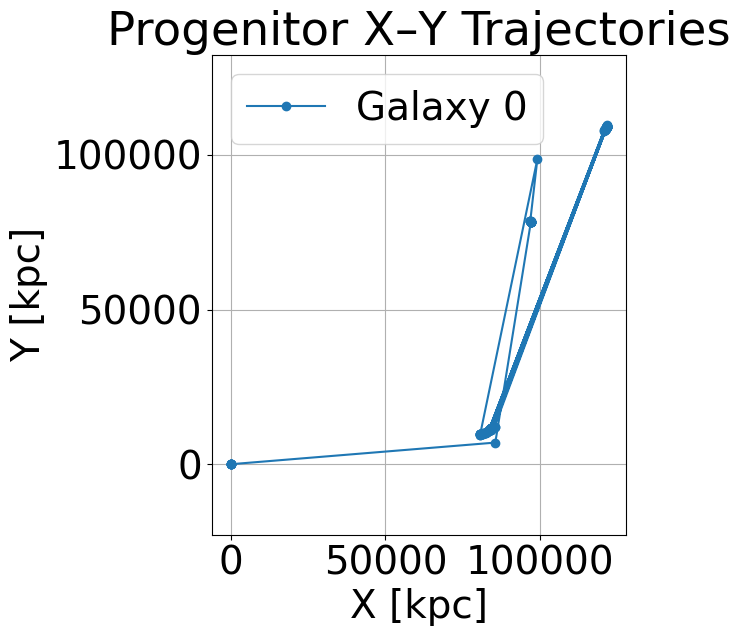

In [75]:
plot_xy_progenitor_paths('/home/lorenzong/analize_simba_cgm/output/fits/progenitors_files/progenitors_recursive_0.fits', '/home/lorenzong/analize_simba_cgm/output/fits/progenitors_files/progenitors_recursive_1.fits')


In [91]:
f = h5py.File('/media/lorenzong/Data1/SIMBA_catalogs/m100n1024_045.hdf5', 'r')
groupids = f['galaxy_data']['GroupID'][:]
np.all(groupids == np.arange(len(groupids)))


True